In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy import signal
import sys

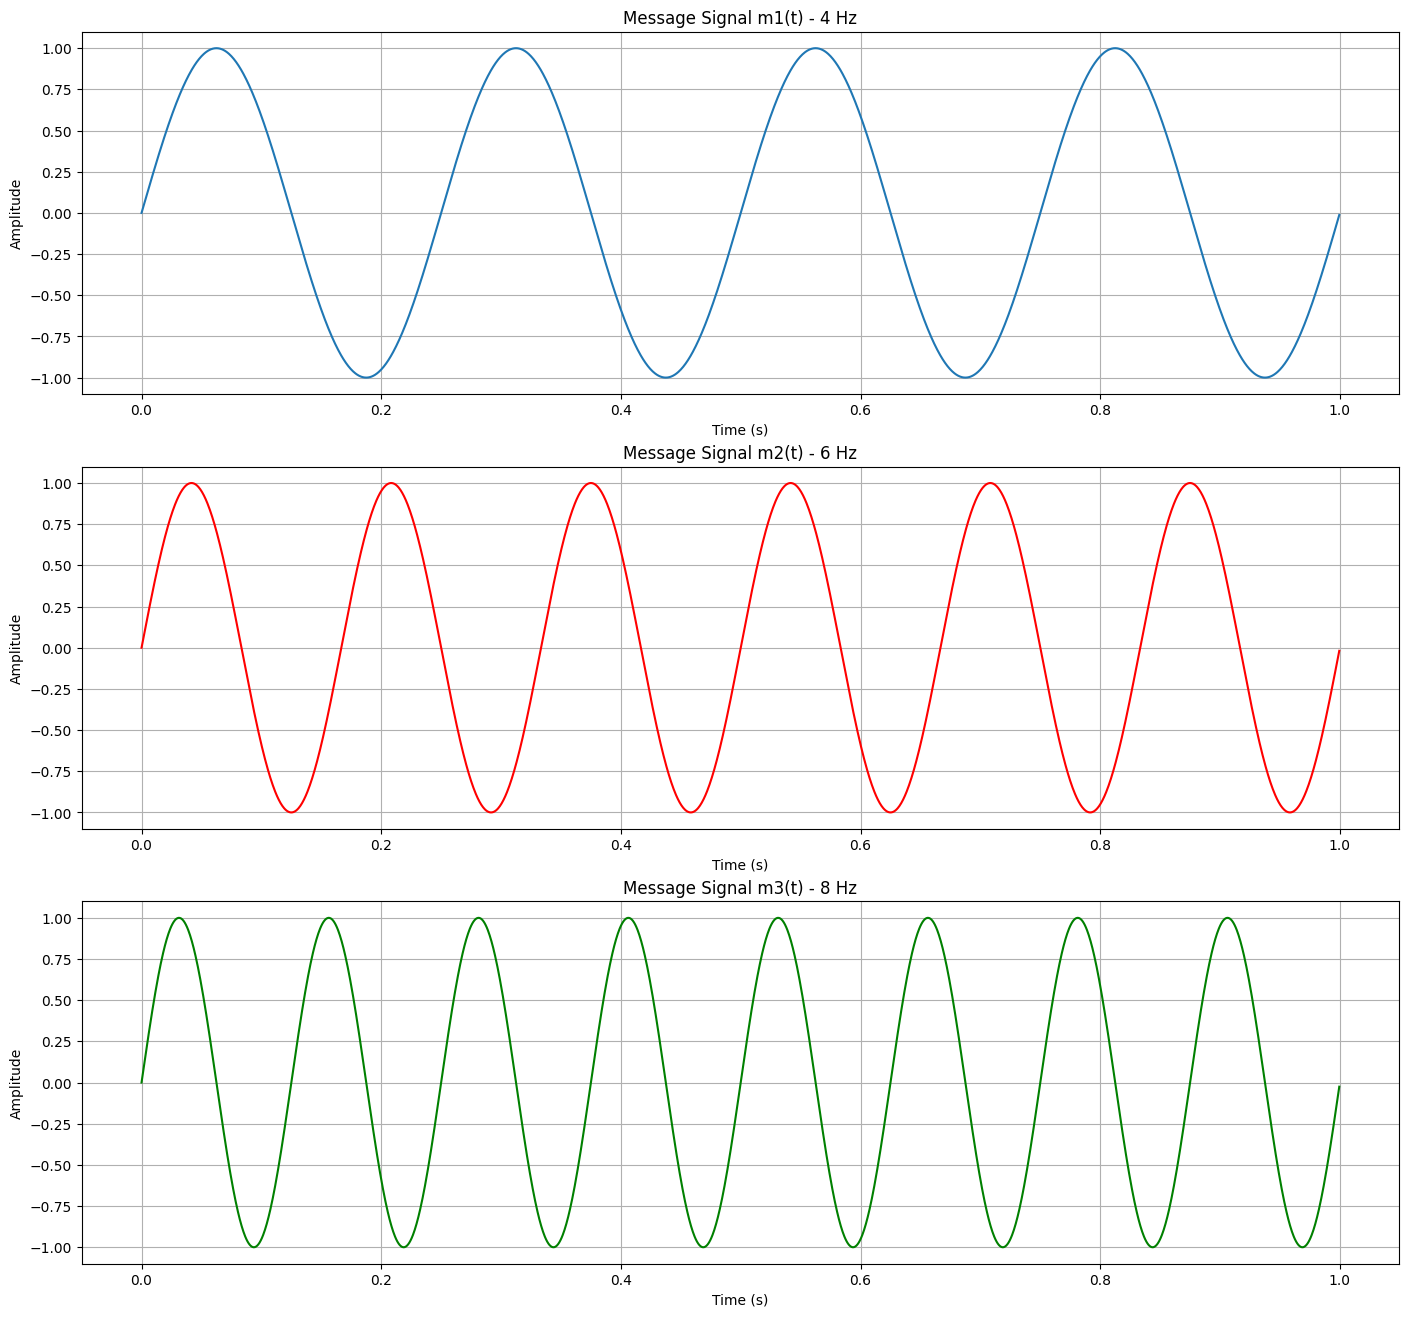

In [2]:
# Sampling
fs = 2000
t = np.arange(0, 1, 1/fs)
# Frequency of the message signals
fm1 = 4
fm2=6
fm3=8
# Message signals
m1 = np.sin(2 * np.pi * fm1 * t)  # 4 Hz
m2 = np.sin(2 * np.pi * fm2 * t)  # 6 Hz
m3 = np.sin(2 * np.pi * fm3 * t)  # 8 Hz

fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,16))
ax1.plot(t,m1)
ax1.set_title('Message Signal m1(t) - 4 Hz')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid()
ax2.plot(t,m2,color='red')
ax2.set_title('Message Signal m2(t) - 6 Hz')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.grid()

ax3.plot(t,m3,color='green')
ax3.set_title('Message Signal m3(t) - 8 Hz')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.grid()
# plt.savefig('Message_Signals.png')

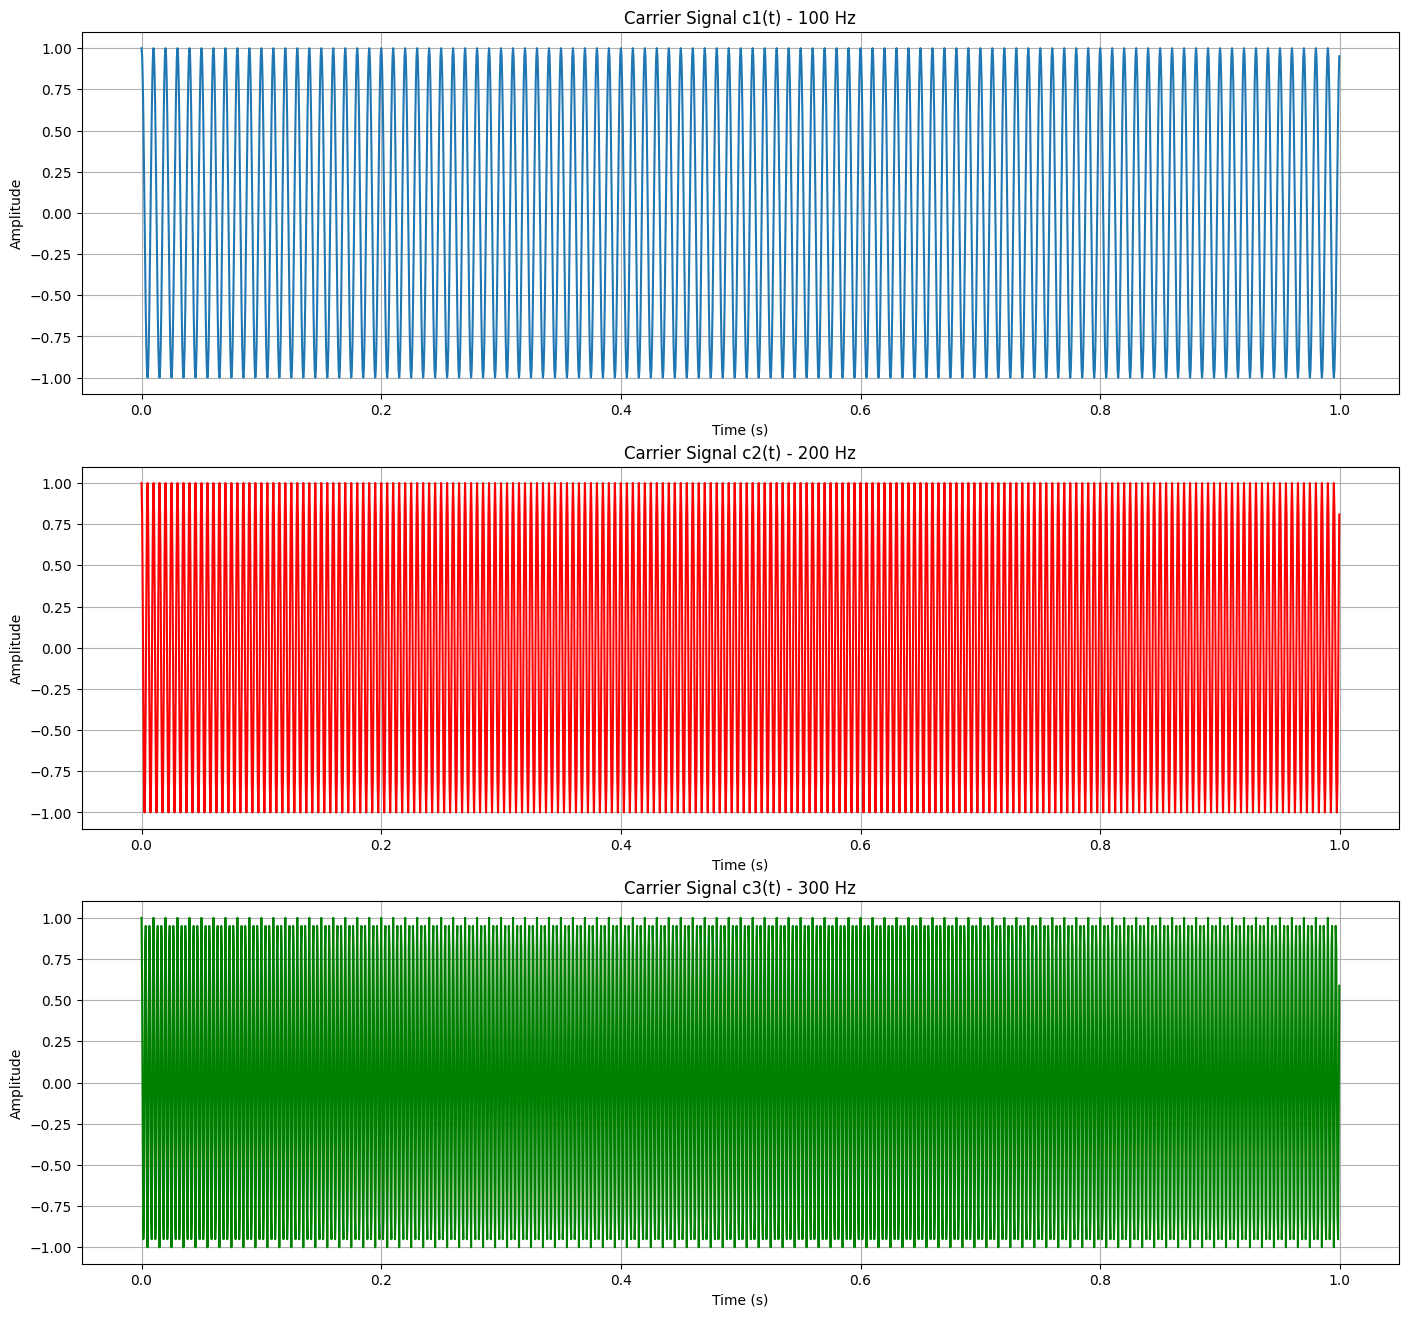

In [3]:
# Carrier Signal
fc1 = 100
fc2 = 200
fc3 = 300
c1 = np.cos(2 * np.pi * fc1 * t)  # 100 Hz
c2 = np.cos(2 * np.pi * fc2 * t)  # 200 Hz
c3 = np.cos(2 * np.pi * fc3 * t)  # 300 Hz

fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,16))
ax1.plot(t,c1)
ax1.set_title('Carrier Signal c1(t) - 100 Hz')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid()

ax2.plot(t,c2,color='red') 
ax2.set_title('Carrier Signal c2(t) - 200 Hz')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.grid()

ax3.plot(t,c3,color='green')
ax3.set_title('Carrier Signal c3(t) - 300 Hz')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.grid()
# plt.savefig('Carrier_Signals.png')

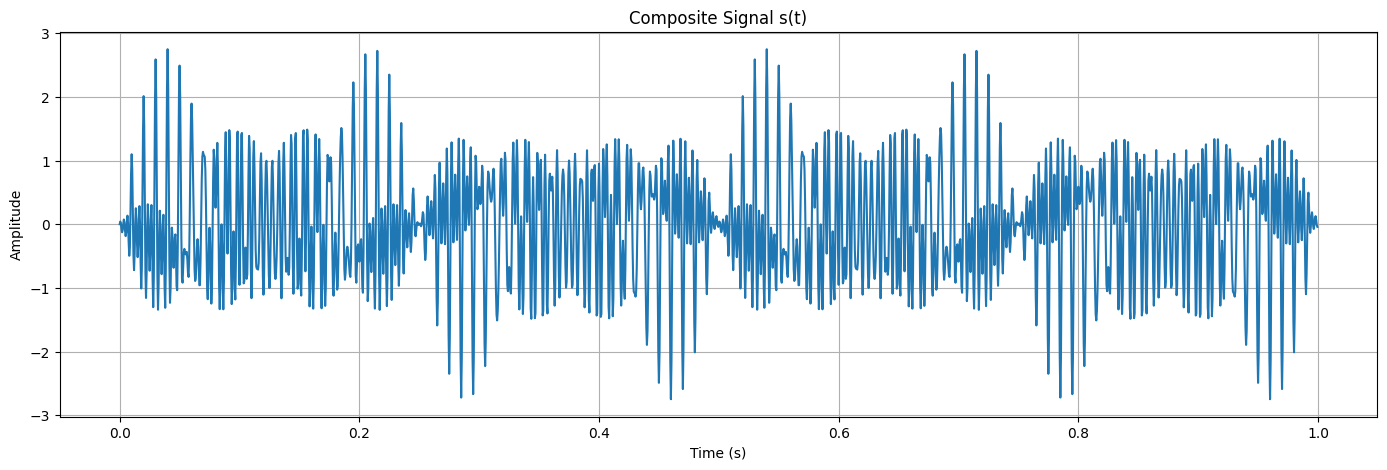

In [4]:
# Composition Signals
s1 = m1 * c1
s2 = m2 * c2
s3 = m3 * c3
s = s1 + s2 + s3
plt.figure(figsize=(17,5))
plt.plot(t,s)
plt.title('Composite Signal s(t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
# plt.savefig('Composite_Signal.png')

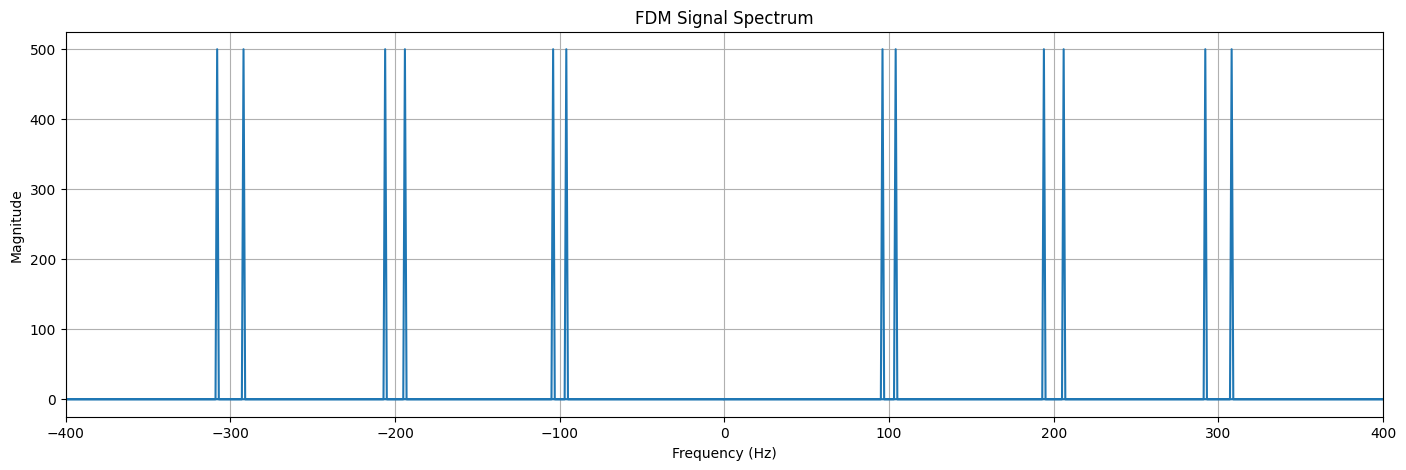

In [17]:
N = len(s)
f = np.arange(-(N//2), N//2, 1)
fdm=np.fft.fftfreq(N, 1/fs)
S = np.fft.fft(s)
plt.figure(figsize=(17,5))
plt.plot(fdm, np.abs(S))
plt.title('FDM Signal Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-400, 400)
plt.grid()

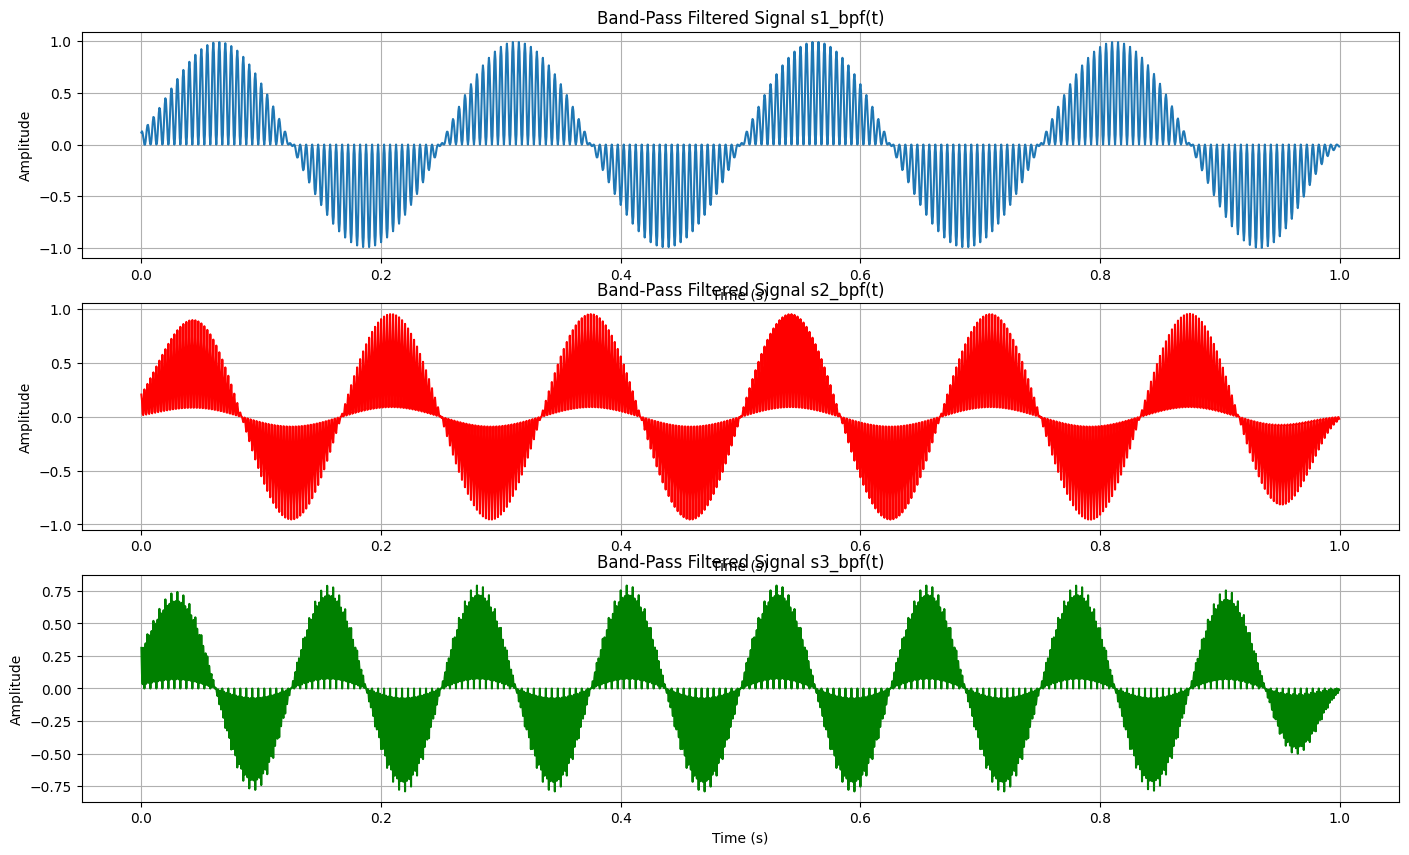

In [5]:
# Band Pass filter
[b1_bpf, a1_bpf] = signal.butter(3, [90/(fs/2), 110/(fs/2)], btype='bandpass')
[b2_bpf, a2_bpf] = signal.butter(3, [190/(fs/2), 210/(fs/2)], btype='bandpass')
[b3_bpf, a3_bpf] = signal.butter(3, [290/(fs/2), 310/(fs/2)], btype='bandpass')
s1_bpf = signal.filtfilt(b1_bpf, a1_bpf, s)
s2_bpf = signal.filtfilt(b2_bpf, a2_bpf, s)
s3_bpf = signal.filtfilt(b3_bpf, a3_bpf, s)
dem1 = s1_bpf * c1
dem2 = s2_bpf * c2
dem3 = s3_bpf * c3
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,10))
ax1.plot(t,dem1)
ax1.set_title('Band-Pass Filtered Signal s1_bpf(t)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid() 

ax2.plot(t,dem2,color='red')
ax2.set_title('Band-Pass Filtered Signal s2_bpf(t)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.grid()

ax3.plot(t,dem3,color='green')
ax3.set_title('Band-Pass Filtered Signal s3_bpf(t)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.grid()

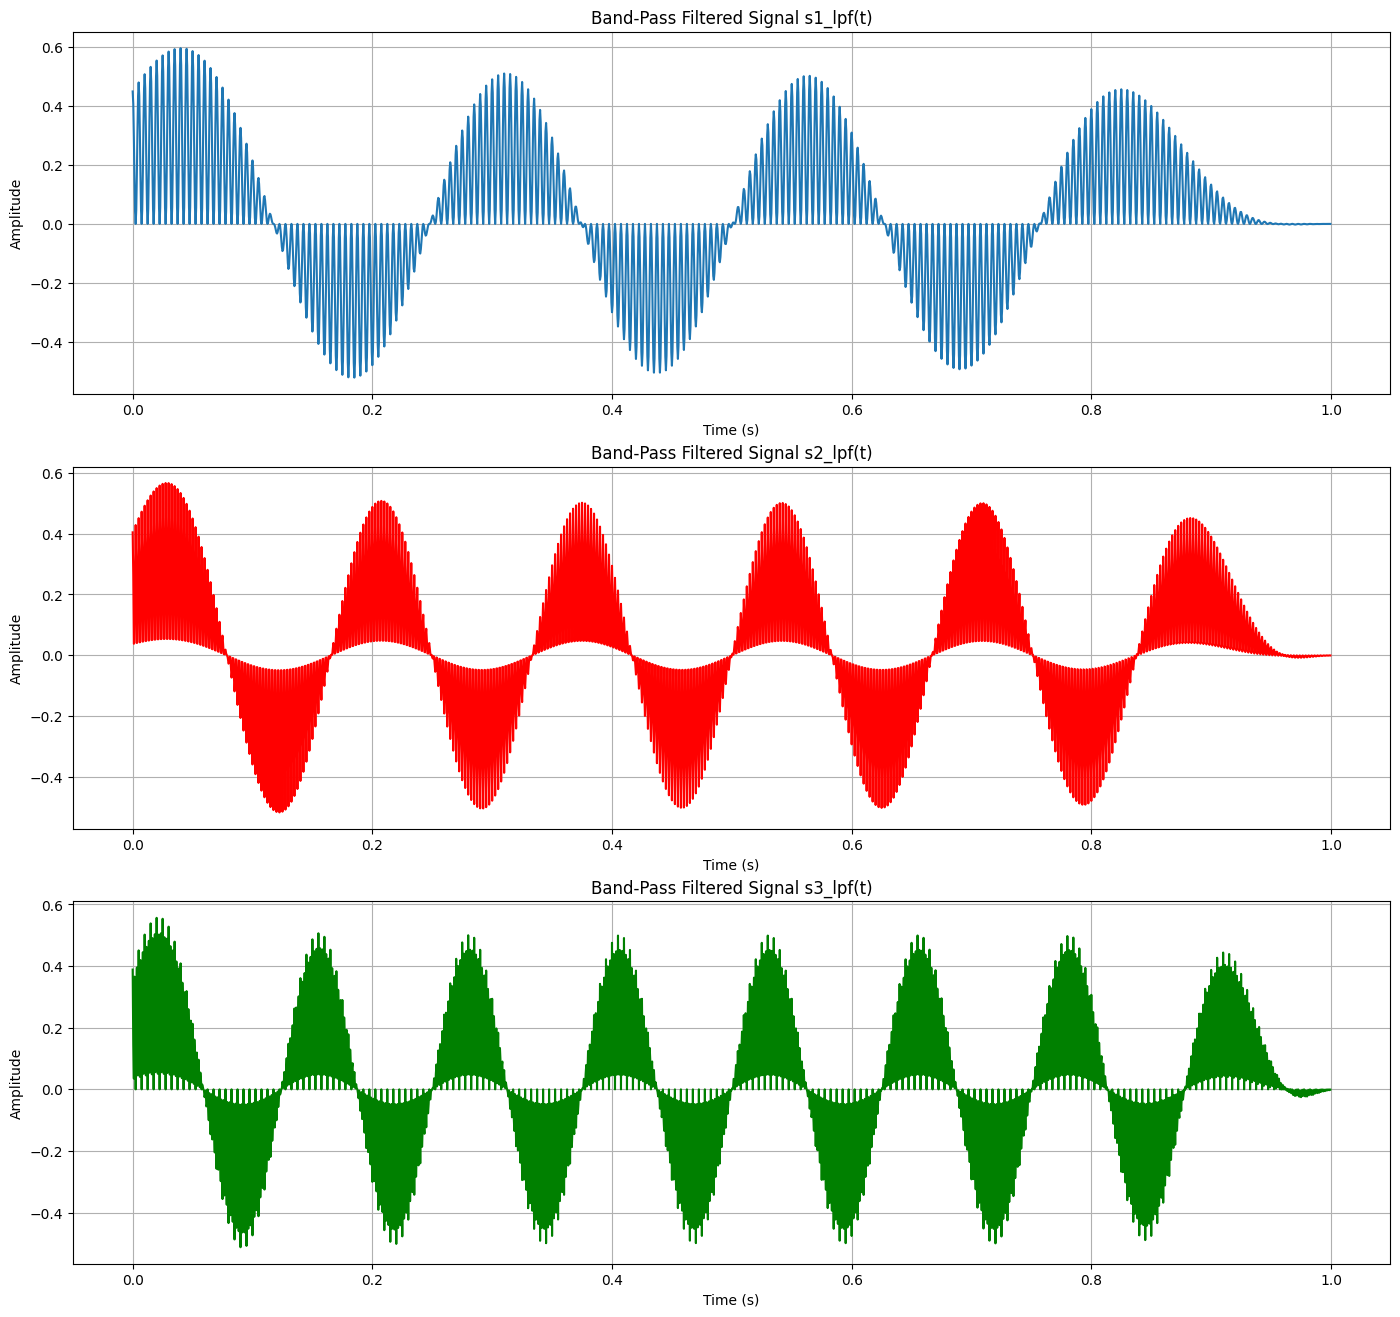

In [6]:
[b1_lpf, a1_lpf] = signal.butter(4, [fc1-fm1, fc1+fm1], btype='bandpass',fs=fs)
[b2_lpf, a2_lpf] = signal.butter(4, [fc2-fm2, fc2+fm2], btype='bandpass',fs=fs)
[b3_lpf, a3_lpf] = signal.butter(4, [fc3-fm3, fc3+fm3], btype='bandpass',fs=fs)
s1_lpf = signal.filtfilt(b1_lpf, a1_lpf, s)
s2_lpf = signal.filtfilt(b2_lpf, a2_lpf, s)
s3_lpf = signal.filtfilt(b3_lpf, a3_lpf, s)
dem1 = s1_lpf * c1
dem2 = s2_lpf * c2
dem3 = s3_lpf * c3
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,16))
ax1.plot(t,dem1)
ax1.set_title('Band-Pass Filtered Signal s1_lpf(t)') 
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid()
ax2.plot(t,dem2,color='red')
ax2.set_title('Band-Pass Filtered Signal s2_lpf(t)')
ax2.set_xlabel('Time (s)') 
ax2.set_ylabel('Amplitude')
ax2.grid()
ax3.plot(t,dem3,color='green')
ax3.set_title('Band-Pass Filtered Signal s3_lpf(t)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.grid()
# plt.savefig('Band-Pass_Filters.png')

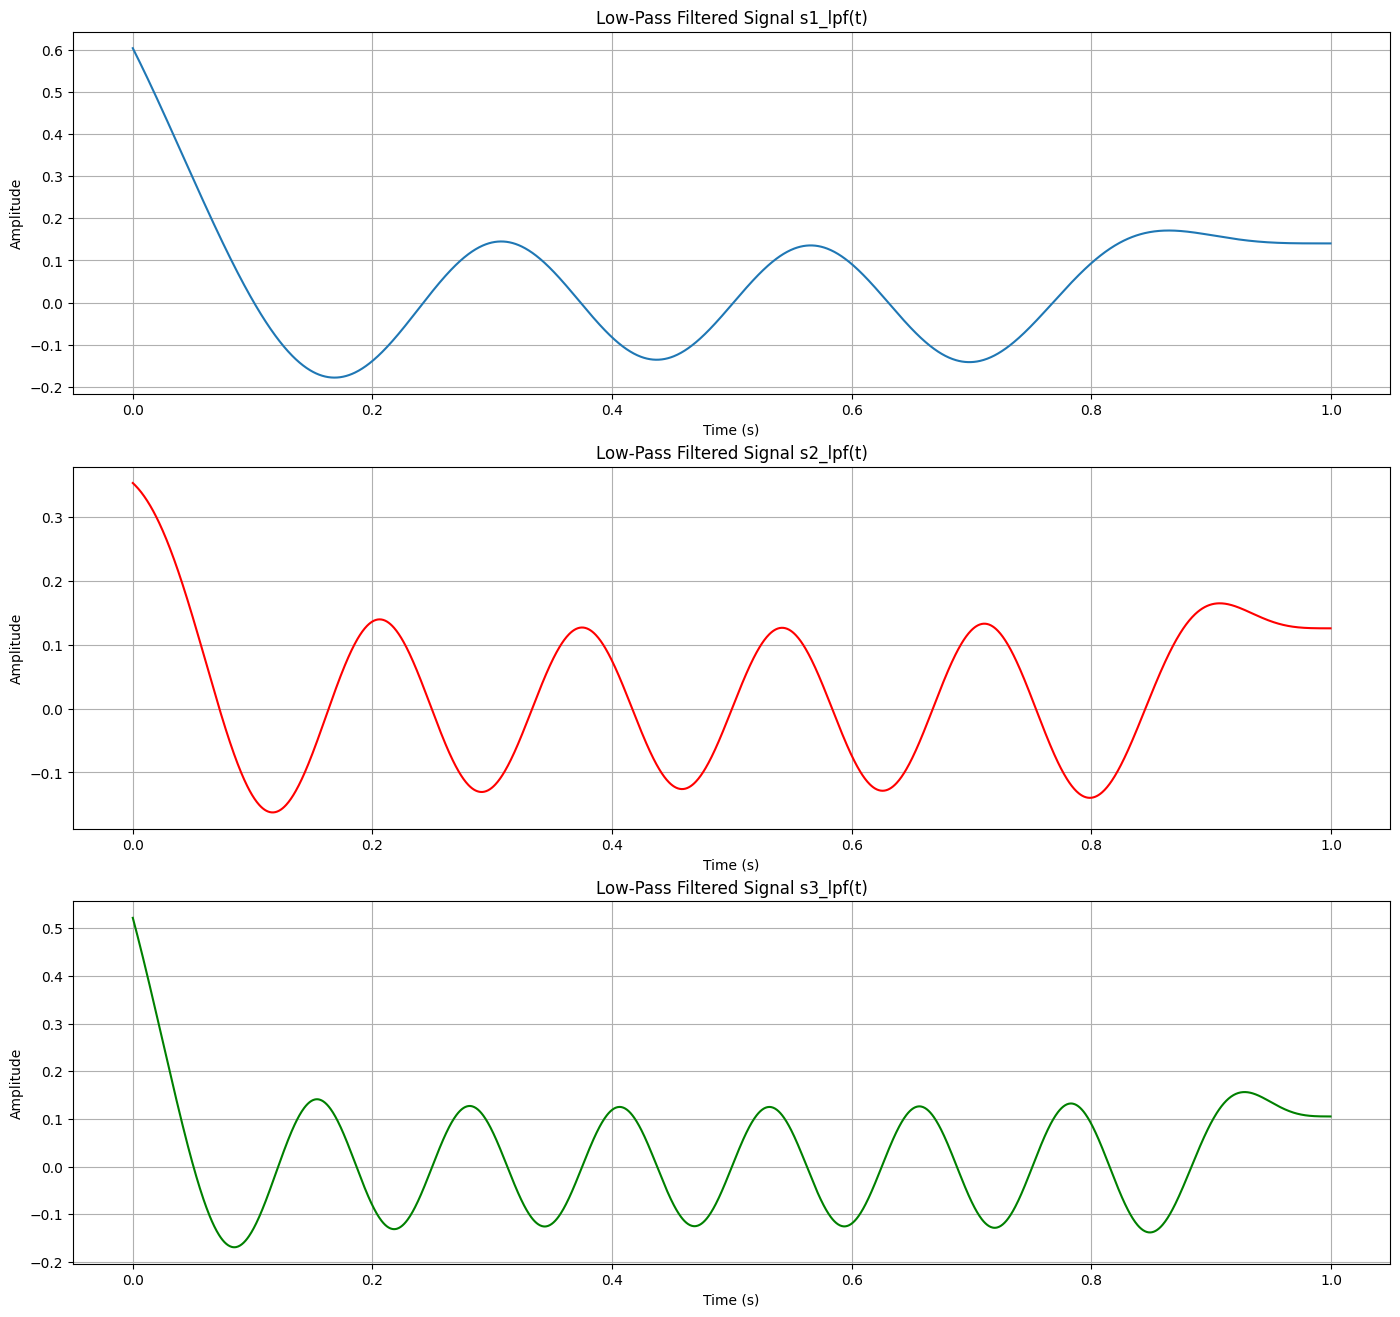

In [7]:
[b1_lpf, a1_lpf] = signal.butter(4, fm1, btype='low',fs=fs)
[b2_lpf, a2_lpf] = signal.butter(4, fm2, btype='low',fs=fs)
[b3_lpf, a3_lpf] = signal.butter(4, fm3, btype='low',fs=fs)
s1_lpf = signal.filtfilt(b1_lpf, a1_lpf, dem1)
s2_lpf = signal.filtfilt(b2_lpf, a2_lpf, dem2)
s3_lpf = signal.filtfilt(b3_lpf, a3_lpf, dem3)
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,16))
ax1.plot(t,s1_lpf)
ax1.set_title('Low-Pass Filtered Signal s1_lpf(t)') 
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid()
ax2.plot(t,s2_lpf,color='red')
ax2.set_title('Low-Pass Filtered Signal s2_lpf(t)')
ax2.set_xlabel('Time (s)') 
ax2.set_ylabel('Amplitude')
ax2.grid()
ax3.plot(t,s3_lpf,color='green')
ax3.set_title('Low-Pass Filtered Signal s3_lpf(t)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.grid()
# plt.savefig('Low-Pass_Filters.png')

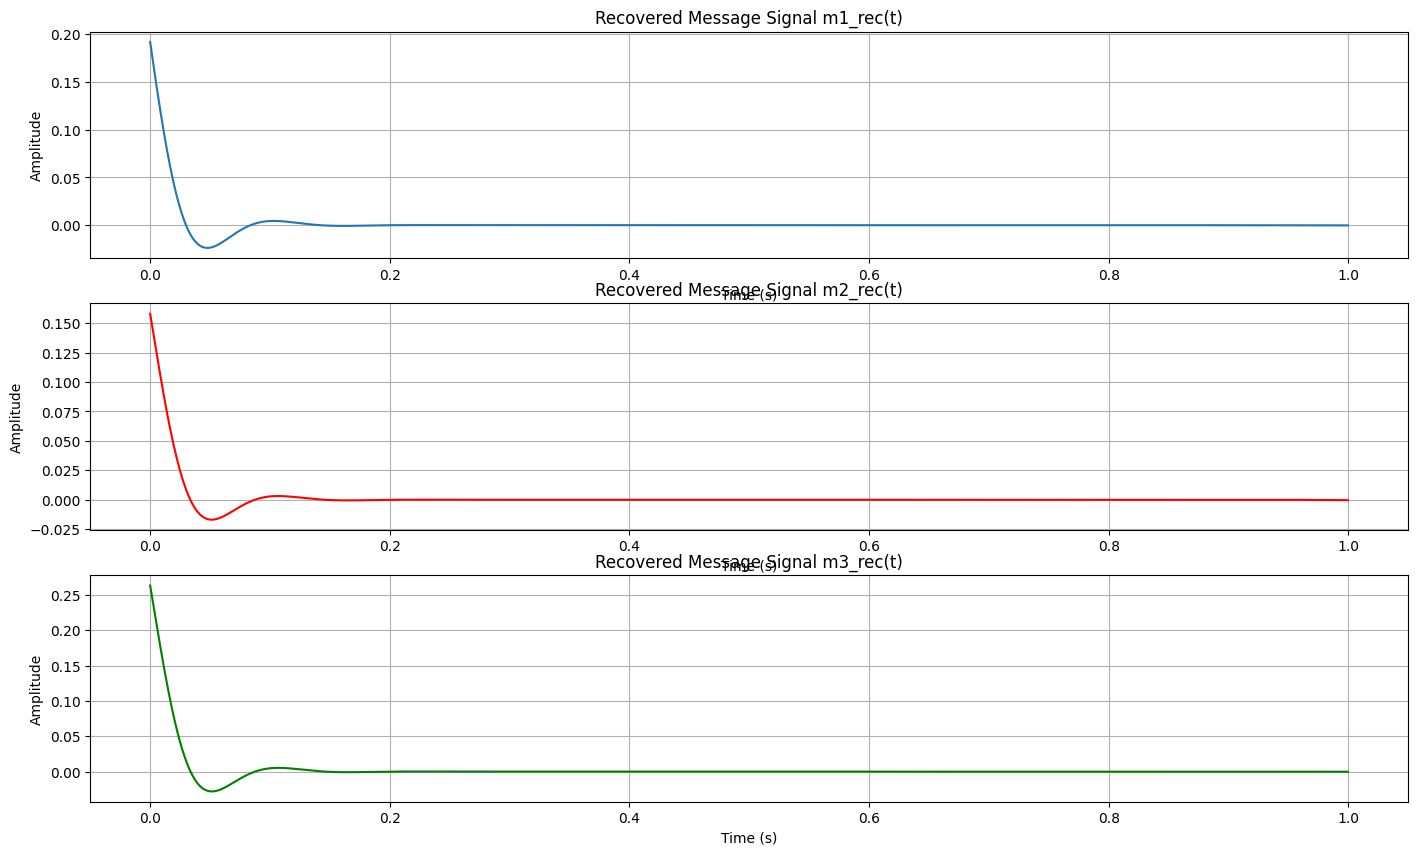

In [8]:
[b1_lpf, a1_lpf] = signal.butter(3, 10/(fs/2), btype='low')
[b2_lpf, a2_lpf] = signal.butter(3, 10/(fs/2), btype='low')
[b3_lpf, a3_lpf] = signal.butter(3, 10/(fs/2), btype='low')
m1_rec = signal.filtfilt(b1_lpf, a1_lpf, s1_bpf)
m2_rec = signal.filtfilt(b2_lpf, a2_lpf, s2_bpf)
m3_rec = signal.filtfilt(b3_lpf, a3_lpf, s3_bpf)

fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,10))
ax1.plot(t,m1_rec)
ax1.set_title('Recovered Message Signal m1_rec(t)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid()

ax2.plot(t,m2_rec,color='red')
ax2.set_title('Recovered Message Signal m2_rec(t)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.grid()

ax3.plot(t,m3_rec,color='green')
ax3.set_title('Recovered Message Signal m3_rec(t)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude')
ax3.grid()